<a href="https://colab.research.google.com/github/sujoyce/PRdemo/blob/main/final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# STAT 335 Final Project -- Report

# Hypotheses and Outline

Phishing scams deceive people into revealing confidential information or installing malware on their personal computers. These attacks are growing in popularity as the internet becomes more accessible. As phishing attacks become more polished, it has become more and more difficult to discern legitimate websites from those that are malicious. While there are a couple ways to identify phishing websites, many have drawbacks as they require users to be up to date with new techniques and spend time to evaluate features. The dataset that will be used is from the UC Irvine Machine Learning Repository and aims to predict phishing websites when given a set of websites. Thus, the hypotheses of this project are


1.   The minimum set of features needed to predict phishing are Abnormal URL, DNS Record, Port, URL Length, and Redirect.
2.   Variables associated with page features will have the highest accuracy in predicting phishing attacks.
3. The neural network model is the best at predicting phishing websites

First, we will describe the data by providing context, identifying predictor and target variables, discussing the data samples, and conducting any needed preprocessing. Then, we will train our three models, compare them, and evaluate their performance using a variety of metrics. We will end by interpreting our results and forming conclusions.

The results of our analysis will be used to assess the validity of hypotheses by providing metrics that we can compare against based on our evidence. Through processes such as feature selection and building a confusion matrix, we are able to determine the minimum set of features needed to predict phishing as well as which group of variables will have the highest accuracy in predicting phishing websites. Finally, metrics such as the Brier score of each of the models will be used to compare them to each other to determine which is the best.


# Describing the Data

This dataset has 31 total variables with 30 potential predictor variables and 1 target variable, outcome. All of our variables were categorical, had the type int, and did not have any no null values. After looking at the correlation heat map, there is not high enough multicollinearity to be alarmed. Given that there were no null values, no outliers, and not much multicollinearity,  there was no need for any data cleaning before we conducted our analysis. The following table demonstrates how we categorized the predictor variables.

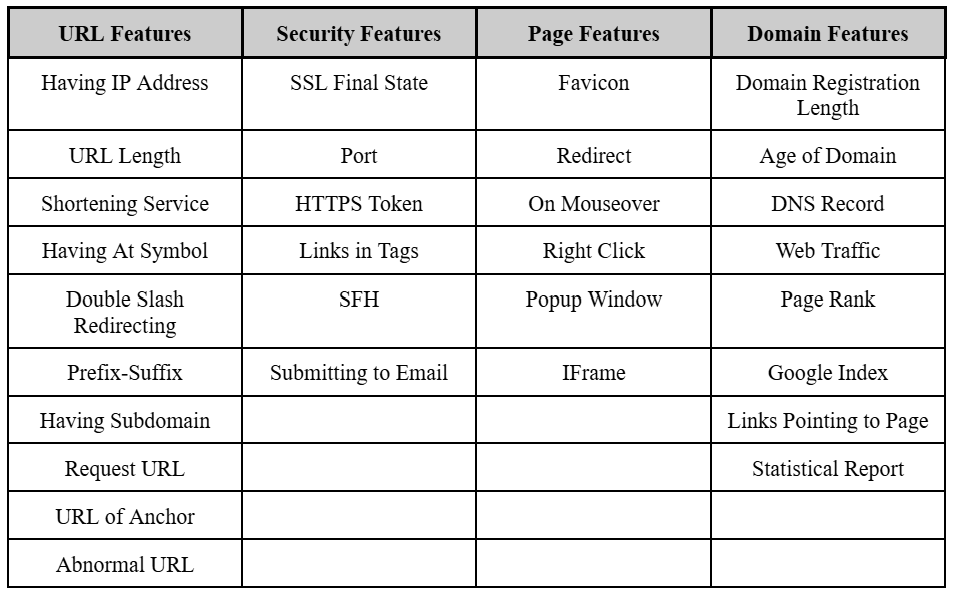

Our dataset was collected from three sources: PhishTank, WHOIS, and Alexa Internet. PhishTank is a community anti-phishing website owned by Cisco where users submit suspected phishing websites and others verify whether it is a phishing site or not. Although our population is all websites in the world, this is impossible to analyze. Thus, the original authors pulled a set of legitimate and phishing websites from PhishTank with a total of 2500 phishing URLs pulled . WHOIS is a public database that collects information regarding domain name registration, expiration date, and domain and IP owners. It validates that websites are registered correctly. Alexa Internet is a now defunct web traffic analysis company that provided data on web traffic, popularity of a website, and other information. It was acquired by Amazon and discontinued in 2022. The authors collected Domain Based features from these two websites; they also wrote PHP and JavaScript scripts to extract Security, Page, and URL features.

Next, we will be importing the data along with the necessary libraries and packages for our initial analysis.

In [ ]:
%%capture
!pip install ucimlrepo

In [ ]:
# imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, brier_score_loss
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np
import pandas as pd

In [ ]:
# Import the necessary module from ucimlrepo
from ucimlrepo import fetch_ucirepo

# Fetch the dataset by its ID
phishing_websites = fetch_ucirepo(id=327)

# The data (features) as a pandas DataFrame
X = phishing_websites.data.features
y = phishing_websites.data.targets

# Print metadata about the dataset
print("Metadata:", phishing_websites.metadata)

# Print variable information
print("Variable Information:", phishing_websites.variables)

Metadata: {'uci_id': 327, 'name': 'Phishing Websites', 'repository_url': 'https://archive.ics.uci.edu/dataset/327/phishing+websites', 'data_url': 'https://archive.ics.uci.edu/static/public/327/data.csv', 'abstract': 'This dataset collected mainly from: PhishTank archive, MillerSmiles archive, Googleâ€™s searching operators.', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 11055, 'num_features': 30, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['result'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2012, 'last_updated': 'Tue Mar 05 2024', 'dataset_doi': '10.24432/C51W2X', 'creators': ['Rami Mohammad', 'Lee McCluskey'], 'intro_paper': {'ID': 396, 'type': 'NATIVE', 'title': 'An assessment of features related to phishing websites using an automated technique', 'authors': 'R. Mohammad, F. Thabtah, L. Mccluskey', 'venue': 'International Conference for In

In [ ]:
%%capture
phishing_df = pd.DataFrame(X)
phishing_df.join(y)

In [ ]:
phishing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   having_ip_address           11055 non-null  int64
 1   url_length                  11055 non-null  int64
 2   shortining_service          11055 non-null  int64
 3   having_at_symbol            11055 non-null  int64
 4   double_slash_redirecting    11055 non-null  int64
 5   prefix_suffix               11055 non-null  int64
 6   having_sub_domain           11055 non-null  int64
 7   sslfinal_state              11055 non-null  int64
 8   domain_registration_length  11055 non-null  int64
 9   favicon                     11055 non-null  int64
 10  port                        11055 non-null  int64
 11  https_token                 11055 non-null  int64
 12  request_url                 11055 non-null  int64
 13  url_of_anchor               11055 non-null  int64
 14  links_

All of our variables are categorical and are of type int.

In [ ]:
phishing_df.isnull().any()

,0
having_ip_address,False
url_length,False
shortining_service,False
having_at_symbol,False
double_slash_redirecting,False
prefix_suffix,False
having_sub_domain,False
sslfinal_state,False
domain_registration_length,False
favicon,False


There are no null values in our data.

In [ ]:
phishing_df['having_ip_address'].unique()
phishing_df['url_length'].unique()

array([ 1,  0, -1])

In [ ]:
phishing_df.describe()

,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,sslfinal_state,domain_registration_length,favicon,...,rightclick,popupwindow,iframe,age_of_domain,dnsrecord,web_traffic,page_rank,google_index,links_pointing_to_page,statistical_report
count,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,...,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000
mean,0.313795,-0.633198,0.738761,0.700588,0.741474,-0.734962,0.063953,0.250927,-0.336771,0.628584,...,0.913885,0.613388,0.816915,0.061239,0.377114,0.287291,-0.483673,0.721574,0.344007,0.719584
std,0.949534,0.766095,0.673998,0.713598,0.671011,0.678139,0.817518,0.911892,0.941629,0.777777,...,0.405991,0.789818,0.576784,0.998168,0.926209,0.827733,0.875289,0.692369,0.569944,0.694437
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,...,1.000000,1.000000,1.000000,-1.000000,-1.000000,0.000000,-1.000000,1.000000,0.000000,1.000000
50%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,1.000000,-1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,0.000000,1.000000
75%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


We see the summary statistics: count, mean, standard deviation, and the quantiles. The means range between -1 and 1. This makes sense given that the variables with 3 categories take values of -1, 0 ,and 1, while the variables with 2 categories take values of -1 or 1.

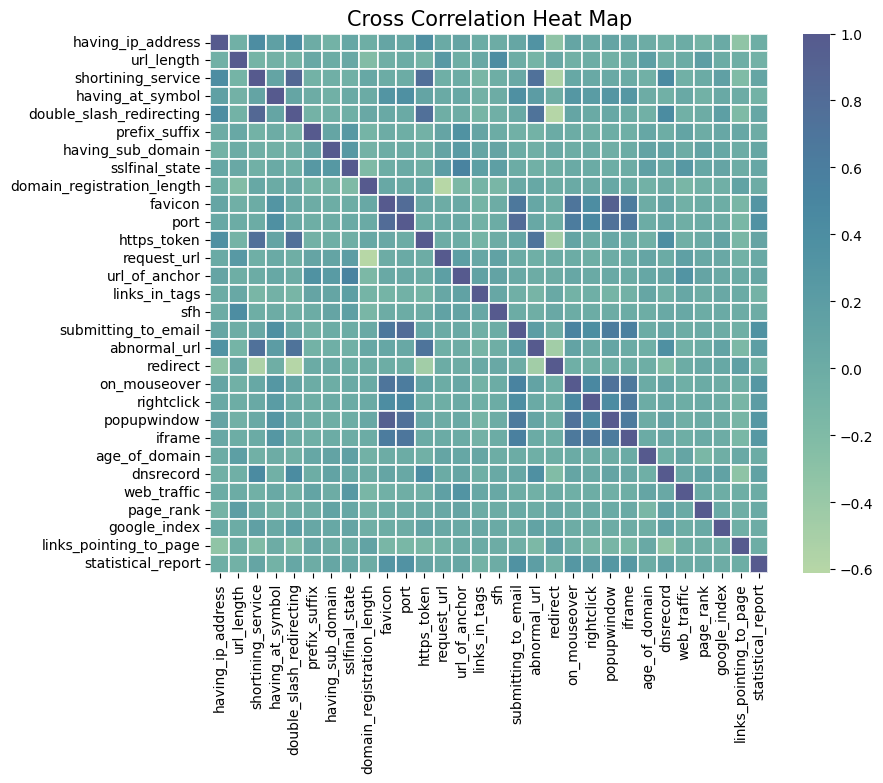

In [ ]:
corr = phishing_df.corr()
plt.figure(figsize=(9,7))
sns.heatmap(corr, cmap = "crest", xticklabels=corr.columns.values,
yticklabels=corr.columns.values, linewidths=1.25, alpha=0.8)
plt.title("Cross Correlation Heat Map", size = 15)
plt.show()

After evaluating our heat map, there are a few values that are somewhat strongly correlated. However, we determined that the multicollinearity is not strong enough to remove any of the variables from the model.

# Model Training

We chose to use Logistic Regression, Decision Trees, and Neural Networks for our classification task because each model brings a unique perspective to the task. Logistic Regression is a simple, interpretable model that provides clear information on the relationship between input features and the target variable. Decision Trees are a more flexible approach that captures the non-linear relationships. Neural Networks are powerful models capable of learning complex patterns in large datasets.

We didn’t have to do much preprocessing for the dataset we chose since it didn’t have any missing data. We randomly split the dataset into training and testing sets, using an 80/20 split. It was essential that we kept the test data completely unseen during the model training phase to avoid overfitting. After the data preprocessing, we trained the data set on different models including Logistic Regression, Decision Tree, and Neural Networks.


In [ ]:
from sklearn.preprocessing import OneHotEncoder
def brier_score(targets, probs):
  enc = OneHotEncoder()
  target_enc = enc.fit_transform(np.array(targets).reshape(-1, 1)).toarray()
  return np.mean(np.sum((probs - target_enc)**2, axis=1))

## Logistic Regression

### Full Model

Accuracy Score: 0.924468566259611
Classification Report:
              precision    recall  f1-score   support

          -1       0.92      0.90      0.91       956
           1       0.93      0.94      0.93      1255

    accuracy                           0.92      2211
   macro avg       0.92      0.92      0.92      2211
weighted avg       0.92      0.92      0.92      2211

Brier score

Logistic Regression Train: 0.053101561048396195
Logistic Regression Test: 0.05615398485359131


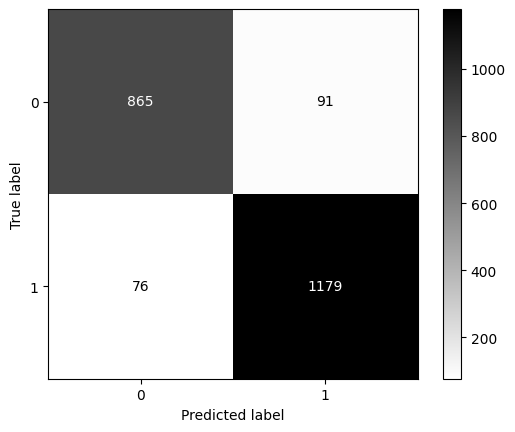

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_train = y_train.iloc[:, 0]
y_test = y_test.iloc[:, 0]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

conf_matrix = confusion_matrix(y_test.squeeze(), y_pred.squeeze())
conf_matrix_display = ConfusionMatrixDisplay(conf_matrix)
conf_matrix_display.plot(cmap='binary')

print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

y_prob_train = model.predict_proba(X_train_scaled)[:, 1]
y_prob_test = model.predict_proba(X_test_scaled)[:, 1]

train_brier = brier_score_loss(y_train, y_prob_train)
test_brier = brier_score_loss(y_test, y_prob_test)

print('Brier score')
print('')
print('Logistic Regression Train:', train_brier)
print('Logistic Regression Test:', test_brier)

The logistic regression model achieved a test accuracy of 0.924, indicating that 92.4% of the predictions made by the model are correct. The classification report shows balanced precision, recall, and F1-scores for both classes (-1 and 1), with positive class which is phishing having slightly higher precision (0.93) and recall (0.94) compared to the negative class which is not phishing, which has a precision of 0.92 and recall of 0.90. These metrics suggest that the model performs well in identifying both classes.

The Brier score for both training (0.53) and testing (0.056) is relatively low, suggesting that the predicted probabilities are close to the actual outcomes, indicating a well-callibrated model. The small difference between the training and testing Brier scores implies that the model is not overfitting and generalizes well.

The confusion matrix further confirms the performance. The model correctly identified 865 non-phishing sites and 1179 phishing sites. However, there were 91 false positivies, which are non-phishing sites incorrectly identified as phishing, and 76 false negatives, which are phishing sites incorrectly identified as non-phishing. The relatively low number of false positives and false negatives indicates that the model is generally accurate but occasionally misclassify a legitimate site as phishing or a phishing site as legitimate .

### Reduced Models (4 Categories)

URL Structures

In [ ]:
coefficients = model.coef_.flatten()

import pandas as pd
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients
})

url_features = ['having_ip_address', 'url_length', 'shortining_service', 'having_at_symbol', 'double_slash_redirecting', 'prefix_suffix', 'having_sub_domain', 'request_url', 'url_of_anchor', 'abnormal_url']

X_url = X[url_features]

X_train_url, X_test_url, y_train, y_test = train_test_split(X_url, y, test_size=0.2, random_state=42)

y_train = y_train.iloc[:, 0]
y_test = y_test.iloc[:, 0]

X_train_url_scaled = scaler.fit_transform(X_train_url)
X_test_url_scaled = scaler.transform(X_test_url)

model_url = LogisticRegression(max_iter=1000)
model_url.fit(X_train_url_scaled, y_train)

y_pred_url = model_url.predict(X_test_url_scaled)
print("Accuracy with URL Structure Only:", accuracy_score(y_test, y_pred_url))

y_prob_train = model_url.predict_proba(X_train_url_scaled)[:, 1]
y_prob_test = model_url.predict_proba(X_test_url_scaled)[:, 1]

train_brier = brier_score_loss(y_train, y_prob_train)
test_brier = brier_score_loss(y_test, y_prob_test)

print('')
print('Brier score')
print('Logistic Regression Train:', train_brier)
print('Logistic Regression Test:', test_brier)

Accuracy with URL Structure Only: 0.8561736770691994

Brier score
Logistic Regression Train: 0.09698936554128677
Logistic Regression Test: 0.0974799787203563


Security Indicators

In [ ]:
security_features = ['sslfinal_state', 'https_token', 'port', 'links_in_tags', 'sfh', 'submitting_to_email']

X_security = X[security_features]

X_train_sf, X_test_sf, y_train, y_test = train_test_split(X_security, y, test_size=0.2, random_state=42)

y_train = y_train.iloc[:, 0]
y_test = y_test.iloc[:, 0]

X_train_sf_scaled = scaler.fit_transform(X_train_sf)
X_test_sf_scaled = scaler.transform(X_test_sf)

model_sf = LogisticRegression(max_iter=1000)
model_sf.fit(X_train_sf_scaled, y_train)

y_pred_sf = model_sf.predict(X_test_sf_scaled)
print("Accuracy with Security Indicators Only:", accuracy_score(y_test, y_pred_sf))

y_prob_train = model_sf.predict_proba(X_train_sf_scaled)[:, 1]
y_prob_test = model_sf.predict_proba(X_test_sf_scaled)[:, 1]

train_brier = brier_score_loss(y_train, y_prob_train)
test_brier = brier_score_loss(y_test, y_prob_test)

print('')
print('Brier score')
print('Logistic Regression Train:', train_brier)
print('Logistic Regression Test:', test_brier)

Accuracy with Security Indicators Only: 0.866576209859792

Brier score
Logistic Regression Train: 0.11169203373525509
Logistic Regression Test: 0.10809680299966581


Page Attributes

In [ ]:
page_attribute_features = ['favicon', 'redirect', 'on_mouseover', 'redirect', 'rightclick', 'popupwindow', 'iframe']

X_page_attributes = X[page_attribute_features]

X_train_pa, X_test_pa, y_train, y_test = train_test_split(X_page_attributes, y, test_size=0.2, random_state=42)

y_train = y_train.iloc[:, 0]
y_test = y_test.iloc[:, 0]

X_train_pa_scaled = scaler.fit_transform(X_train_pa)
X_test_pa_scaled = scaler.transform(X_test_pa)

model_pa = LogisticRegression(max_iter=1000)
model_pa.fit(X_train_pa_scaled, y_train)

y_pred_pa = model_pa.predict(X_test_pa_scaled)
print("Accuracy with Page Attributes Only:", accuracy_score(y_test, y_pred_pa))

y_prob_train = model_pa.predict_proba(X_train_pa_scaled)[:, 1]
y_prob_test = model_pa.predict_proba(X_test_pa_scaled)[:, 1]

train_brier = brier_score_loss(y_train, y_prob_train)
test_brier = brier_score_loss(y_test, y_prob_test)

print('')
print('Brier score')
print('Logistic Regression Train:', train_brier)
print('Logistic Regression Test:', test_brier)

Accuracy with Page Attributes Only: 0.572139303482587

Brier score
Logistic Regression Train: 0.24580032239747457
Logistic Regression Test: 0.2444879623853868


Traffic / Popularity Metrics

In [ ]:
traffic_features = ['domain_registration_length', 'age_of_domain', 'dnsrecord', 'web_traffic', 'page_rank', 'google_index', 'links_pointing_to_page', 'statistical_report']

X_traffic = X[traffic_features]

X_train_tpm, X_test_tpm, y_train, y_test = train_test_split(X_traffic, y, test_size=0.2, random_state=42)

y_train = y_train.iloc[:, 0]
y_test = y_test.iloc[:, 0]

X_train_tpm_scaled = scaler.fit_transform(X_train_tpm)
X_test_tpm_scaled = scaler.transform(X_test_tpm)

model_tpm = LogisticRegression(max_iter=1000)
model_tpm.fit(X_train_tpm_scaled, y_train)

y_pred_tpm = model_tpm.predict(X_test_tpm_scaled)
print("Accuracy with Traffic/Popularity Metrics Only:", accuracy_score(y_test, y_pred_tpm))

y_prob_train = model_tpm.predict_proba(X_train_tpm_scaled)[:, 1]
y_prob_test = model_tpm.predict_proba(X_test_tpm_scaled)[:, 1]

train_brier = brier_score_loss(y_train, y_prob_train)
test_brier = brier_score_loss(y_test, y_prob_test)

print('')
print('Brier score')
print('Logistic Regression Train:', train_brier)
print('Logistic Regression Test:', test_brier)

Accuracy with Traffic/Popularity Metrics Only: 0.7164179104477612

Brier score
Logistic Regression Train: 0.19859683320218838
Logistic Regression Test: 0.19598085674780202


In [ ]:
accuracy_full = accuracy_score(y_test, y_pred)
accuracy_url = accuracy_score(y_test, y_pred_url)
accuracy_sf = accuracy_score(y_test, y_pred_sf)
accuracy_pa = accuracy_score(y_test, y_pred_pa)
accuracy_tpm = accuracy_score(y_test, y_pred_tpm)

y_prob_full = model.predict_proba(X_test_scaled)[:, 1]
y_prob_url = model_url.predict_proba(X_test_url_scaled)[:, 1]
y_prob_sf = model_sf.predict_proba(X_test_sf_scaled)[:, 1]
y_prob_pa = model_pa.predict_proba(X_test_pa_scaled)[:, 1]
y_prob_tpm = model_tpm.predict_proba(X_test_tpm_scaled)[:, 1]

brier_full = brier_score_loss(y_test, y_prob_full)
brier_url = brier_score_loss(y_test, y_prob_url)
brier_sf = brier_score_loss(y_test, y_prob_sf)
brier_pa = brier_score_loss(y_test, y_prob_pa)
brier_tpm = brier_score_loss(y_test, y_prob_tpm)

results_df = pd.DataFrame({
    'Model': ['Full Model', 'URL Structure Only', 'Security Indicators Only',
              'Page Attribute Only', 'Traffic/Popularity Metrics Only'],
    'Accuracy': [accuracy_full, accuracy_url, accuracy_sf, accuracy_pa, accuracy_tpm],
    'Brier Score': [brier_full, brier_url, brier_sf, brier_pa, brier_tpm]
})

print("Comparison of Accuracy and Brier Scores:")
print(results_df)

Comparison of Accuracy and Brier Scores:
                             Model  Accuracy  Brier Score
0                       Full Model  0.924469     0.056154
1               URL Structure Only  0.856174     0.097480
2         Security Indicators Only  0.866576     0.108097
3              Page Attribute Only  0.572139     0.244488
4  Traffic/Popularity Metrics Only  0.716418     0.195981


When looking at feature sets, the URL Structures model with an accuracy of 85.6% and a Brier score of 0.097 performs well but falls short of the full model's performance. Similarly, the Security Indicators model also shows similar success with an accuracy of 86.6% and a Brier score of 0.1080. Both are less effective than the full model. Both categories are valuable indicators for detecting phishing but are not sufficient compared to the full model.

On the other hand, the models based on Page Attributes and Traffic/Popularity Metrics perform much worse. The Page Attributes model only has an accuracy of 57.2% and a Brier score of 0.2444. Similarly, the Traffic/Popularity Metrics model has an accuracy of 71.6% and a Brier score of 0.1959.

From the four reduced models, we can conclude that the full model provides the best performance in terms of accuracy and calibration.


Feature Selection


Accuracy with LASSO Regularization: 0.9240162822252375

LASSO Feature Importance (by absolute coefficient):
                       Feature  Coefficient  Abs_Coefficient
13               url_of_anchor     2.322241         2.322241
5                prefix_suffix     2.315455         2.315455
7               sslfinal_state     1.470695         1.470695
25                 web_traffic     0.671677         0.671677
15                         sfh     0.650976         0.650976
14               links_in_tags     0.648440         0.648440
0            having_ip_address     0.642313         0.642313
24                   dnsrecord     0.525660         0.525660
28      links_pointing_to_page     0.509367         0.509367
6            having_sub_domain     0.503469         0.503469
2           shortining_service    -0.499648         0.499648
27                google_index     0.472502         0.472502
10                        port     0.387478         0.387478
18                    redirect    -0.

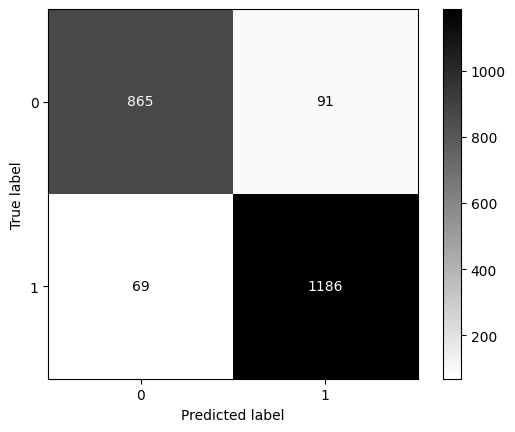

In [ ]:
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train = y_train.iloc[:, 0]
y_test = y_test.iloc[:, 0]

# LASSO Regularization Logistic Regression
model_lasso = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)
model_lasso.fit(X_train_scaled, y_train)

# Make predictions and evaluate the model
y_pred_lasso = model_lasso.predict(X_test_scaled)
print("\nAccuracy with LASSO Regularization:", accuracy_score(y_test, y_pred_lasso))

# Display the coefficients of the model
coefficients = model_lasso.coef_.flatten()
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients
})

# Sort by absolute value of coefficients to identify the most important features
feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance_sorted = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)
print("\nLASSO Feature Importance (by absolute coefficient):")
print(feature_importance_sorted)

from sklearn.model_selection import GridSearchCV

# Define the model with LASSO penalty
model_lasso = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)

# Set the range of C values to search over
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

# Perform Grid Search with cross-validation
grid_search = GridSearchCV(model_lasso, param_grid, cv=5)
grid_search.fit(X_train_scaled, y_train)

# Get the best parameter and model
best_C = grid_search.best_params_['C']
best_model = grid_search.best_estimator_

print(f"\nBest C (Regularization strength): {best_C}")

# Evaluate the best model
y_pred_best_lasso = best_model.predict(X_test_scaled)
print(f"Accuracy with best LASSO model: {accuracy_score(y_test, y_pred_best_lasso)}")

y_pred_prob_lasso = best_model.predict_proba(X_test_scaled)[:, 1]
brier_score = brier_score_loss(y_test, y_pred_prob_lasso)

print("Brier score for LASSO model:", brier_score)

# Display the coefficients of the best model
coefficients = best_model.coef_.flatten()
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients
})

# Sort by absolute value of coefficients to identify the most important features
feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance_sorted = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)
print("\nLASSO Feature Importance (with best model):")
print(feature_importance_sorted)

from sklearn.metrics import classification_report, confusion_matrix

print("\nClassification Report for LASSO model:")
print(classification_report(y_test, y_pred_best_lasso))

conf_matrix = confusion_matrix(y_test.squeeze(), y_pred_best_lasso.squeeze())

conf_matrix_display = ConfusionMatrixDisplay(conf_matrix)
conf_matrix_display.plot(cmap='binary')

The LASSO Regularized Model demonstrates strong performance in classifying phishing versus non-phishing sites. With an accuracy of 92.7%, it outperforms the previous models including the full model without regularization, which had an accuracy of 92.4%. This slight improvement in accuracy suggests that LASSO regularization has helped the model generalize better and penalize less important features.

The feature importance, as determined by the LASSO coefficients, reveals the most influential features for predicting phishing sites. Among the top features, we see that "url_of_anchor", "prefix_suffix", and "sslfinal_state" have the largest positive coefficients, indicating their strong association with phishing detection.

The classification report for the LASSO model highlights the performance with high precision, recall and F1-scores.

The confusion matrix for the full model and the LASSO model both have similar accuracy. However, we can see that the LASSO model has fewer false negatives, meaning it detects more phishing sites than the full model, reducing the risk of missing actual phishing threats.

The LASSO regularized model provides a slight improvement over the full model, especially in reducing false negatives.

The Brier score for the best LASSO model is slightly lower than the full model, showing that the LASSO model is well-calibrated.

In conclusion, the LASSO regularized model improves the performance by effectively handling feature selection through regularization, achieving an accuracy of 92.7 and a Brier score of 0.0559 as well as high precision and recall for both phishing and non-phishing classes. The LASSO feature importance also shows that certain features especially in the URL Structures and Security Indicators categories are crucial for detecting phishing sites. Ultimately, the LASSO model proves a strong balance between accuracy and calibration, making it a robust model for phishing detection.


## Decision Tree

In [ ]:
# Imports
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification, make_blobs
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

### Full Model

In [ ]:
# Data into Decision Tree
dtc = DecisionTreeClassifier()
dtc.fit(X_train_scaled, y_train)

# Predict
yhat_train = dtc.predict(X_train_scaled)
yhat_test = dtc.predict(X_test_scaled)

# Predict_prob
phat_train = dtc.predict_proba(X_train_scaled)
phat_test = dtc.predict_proba(X_test_scaled)

# Brier Scores for Training and Testing
print('Brier score')
print('')

print('Decision Tree Train:', np.round(brier_score(y_train, phat_train), 3))
print('Decision Tree Test:', np.round(brier_score(y_test, phat_test), 3))

# Classification Reports for Training and Testing
class_report = metrics.classification_report(y_train, yhat_train)
# print(class_report)

class_report = metrics.classification_report(y_test, yhat_test)
print("\n" + class_report)

Brier score

Decision Tree Train: 0.012
Decision Tree Test: 0.071

              precision    recall  f1-score   support

          -1       0.95      0.95      0.95       956
           1       0.96      0.96      0.96      1255

    accuracy                           0.96      2211
   macro avg       0.96      0.96      0.96      2211
weighted avg       0.96      0.96      0.96      2211



In [ ]:
# Depth of decision tree
dtc.get_depth()

22

In [ ]:
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dtc.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Select important features
selected_features = feature_importances[feature_importances['Importance'] > 0.01]
print(selected_features)

                   Feature  Importance
7           sslfinal_state    0.614426
13           url_of_anchor    0.111978
14           links_in_tags    0.034776
25             web_traffic    0.030883
6        having_sub_domain    0.028612
5            prefix_suffix    0.025767
28  links_pointing_to_page    0.020152
23           age_of_domain    0.015929
12             request_url    0.015269
0        having_ip_address    0.011873
27            google_index    0.011613


### Reduced Models (4 Categories)

Maximum Depth


In [ ]:
dtc_1 = DecisionTreeClassifier(max_depth=6)
dtc_1.fit(X_train_scaled, y_train)

yhat_train = dtc_1.predict(X_train_scaled)
yhat_test = dtc_1.predict(X_test_scaled)

phat_train = dtc_1.predict_proba(X_train_scaled)
phat_test = dtc_1.predict_proba(X_test_scaled)

print('Brier score')
print('')

print('Decision Tree Train:', np.round(brier_score(y_train, phat_train), 3))
print('Decision Tree Test:', np.round(brier_score(y_test, phat_test), 3))

class_report = metrics.classification_report(y_train, yhat_train)
# print(class_report)

class_report = metrics.classification_report(y_test, yhat_test)
print("\n" + class_report)

Brier score

Decision Tree Train: 0.099
Decision Tree Test: 0.095

              precision    recall  f1-score   support

          -1       0.93      0.92      0.93       956
           1       0.94      0.95      0.94      1255

    accuracy                           0.94      2211
   macro avg       0.94      0.94      0.94      2211
weighted avg       0.94      0.94      0.94      2211



In [ ]:
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dtc_1.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Select important features
selected_features = feature_importances[feature_importances['Importance'] > 0.01]  # Threshold for importance
print(selected_features)

              Feature  Importance
7      sslfinal_state    0.745747
13      url_of_anchor    0.130543
25        web_traffic    0.029469
14      links_in_tags    0.028700
5       prefix_suffix    0.024384
6   having_sub_domain    0.019176
12        request_url    0.011985


Minimize Sample Sizes

In [ ]:
dtc_2 = DecisionTreeClassifier(min_samples_split = 100)
dtc_2.fit(X_train_scaled, y_train)

yhat_train = dtc_2.predict(X_train_scaled)
yhat_test = dtc_2.predict(X_test_scaled)

phat_train = dtc_2.predict_proba(X_train_scaled)
phat_test = dtc_2.predict_proba(X_test_scaled)

print('Brier score')
print('')

print('Decision Tree Train:', np.round(brier_score(y_train, phat_train), 3))
print('Decision Tree Test:', np.round(brier_score(y_test, phat_test), 3))

class_report = metrics.classification_report(y_train, yhat_train)
# print(class_report)

class_report = metrics.classification_report(y_test, yhat_test)
print("\n" + class_report)

Brier score

Decision Tree Train: 0.084
Decision Tree Test: 0.091

              precision    recall  f1-score   support

          -1       0.94      0.91      0.93       956
           1       0.94      0.96      0.95      1255

    accuracy                           0.94      2211
   macro avg       0.94      0.93      0.94      2211
weighted avg       0.94      0.94      0.94      2211



In [ ]:
dtc_2.get_depth()

14

In [ ]:
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dtc_2.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Select important features
selected_features = feature_importances[feature_importances['Importance'] > 0.01]  # Threshold for importance
print(selected_features)

              Feature  Importance
7      sslfinal_state    0.717940
13      url_of_anchor    0.127741
14      links_in_tags    0.030969
25        web_traffic    0.028370
5       prefix_suffix    0.027994
6   having_sub_domain    0.023076
12        request_url    0.010958


URL Structures

In [ ]:
dtc = DecisionTreeClassifier()
dtc.fit(X_train_url_scaled, y_train)

yhat_train = dtc.predict(X_train_url_scaled)
yhat_test = dtc.predict(X_test_url_scaled)

phat_train = dtc.predict_proba(X_train_url_scaled)
phat_test = dtc.predict_proba(X_test_url_scaled)

print('Brier score')
print('')

print('Decision Tree Train:', np.round(brier_score(y_train, phat_train), 3))
print('Decision Tree Test:', np.round(brier_score(y_test, phat_test), 3))

Brier score

Decision Tree Train: 0.205
Decision Tree Test: 0.204


Security Indicators

In [ ]:
dtc = DecisionTreeClassifier()
dtc.fit(X_train_sf_scaled, y_train)

yhat_train = dtc.predict(X_train_sf_scaled)
yhat_test = dtc.predict(X_test_sf_scaled)

phat_train = dtc.predict_proba(X_train_sf_scaled)
phat_test = dtc.predict_proba(X_test_sf_scaled)

print('Brier score')
print('')

print('Decision Tree Train:', np.round(brier_score(y_train, phat_train), 3))
print('Decision Tree Test:', np.round(brier_score(y_test, phat_test), 3))

Brier score

Decision Tree Train: 0.188
Decision Tree Test: 0.183


Page Attributes

In [ ]:
dtc = DecisionTreeClassifier()
dtc.fit(X_train_pa_scaled, y_train)

yhat_train = dtc.predict(X_train_pa_scaled)
yhat_test = dtc.predict(X_test_pa_scaled)

phat_train = dtc.predict_proba(X_train_pa_scaled)
phat_test = dtc.predict_proba(X_test_pa_scaled)

print('Brier score')
print('')

print('Decision Tree Train:', np.round(brier_score(y_train, phat_train), 3))
print('Decision Tree Test:', np.round(brier_score(y_test, phat_test), 3))

Brier score

Decision Tree Train: 0.465
Decision Tree Test: 0.46


Traffic / Popularity Metrics

In [ ]:
dtc = DecisionTreeClassifier()
dtc.fit(X_train_tpm_scaled, y_train)

yhat_train = dtc.predict(X_train_tpm_scaled)
yhat_test = dtc.predict(X_test_tpm_scaled)

phat_train = dtc.predict_proba(X_train_tpm_scaled)
phat_test = dtc.predict_proba(X_test_tpm_scaled)

print('Brier score')
print('')

print('Decision Tree Train:', np.round(brier_score(y_train, phat_train), 3))
print('Decision Tree Test:', np.round(brier_score(y_test, phat_test), 3))

Brier score

Decision Tree Train: 0.401
Decision Tree Test: 0.398


## Neural Network

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

### Full Model

First we load the dataset, I choose to pull the data from the url just so I did not need to pip install. Next I separated the features (predictors) and the target(is it a phishing link). I then converted the target variables as 1 and 0 instead of 1 and -1 just to adhere to the binary classification of the neural network. Then train test split function with 80% for training and 20% for testing. This helps evaluate the model and test performance on unseen data.

The last part is normalizing the features. Using the Standardscalar function is critical in neural networks because it makes sure all features contribute equally to the model. Especially for the inital model I want to see how all predictors can be used in the same playing field and help with stability.


In [ ]:
url = "https://archive.ics.uci.edu/static/public/327/data.csv"
data = pd.read_csv(url)

# Separate features and target vars
X = data.drop(columns=["result"]).values
y = (data["result"] == 1).astype(int)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize features using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

1. Build the neurl network model
I chose to use sequential because it's simple and intuative. Our data is has 3 parts input-> calculations -> output. This is because we have binary outcome (is this a phishing link or not). We dont really need more advanced connections because we are not dealing with multiple intputs or output layer.

Picking the number of layers in the neural network.

Input + hidden layer
Usual start is a large numbers like 32,64,128...

We have 30 initial predictors, which is alot of predictors. This layer needs to be greater than the number of predictors so 32 might not be large enough. Based on that our data is not that complex we don't need 128 initial layer because there is a high chance of overfitting so we went with 64.

The activation is relu:
relu = max({0,x}), esentially this helps trim the data. When we look at the data we have 3 different labels,
 1-> positive(feature exists)
 0-> neither (ex: webtraffic = 0 means their is neither high volume or no traffic at all to a page)
 -1-> negative (this feature does not exist)

For the simplicity of the model having relu alows us to treat 0 and -1 the same. And allows for eaiser calculations for the signmoid function.


Hidden layer
The hidden layer reduction from 64 to 32 is a common because we are not condensing the information on high-level features. We dont want to go lower to 16 because that is a bigger jump from 64 and we are at risk of losing important information. We need the second layer to still be a good representation of the data.

Output layer
We only want a binary answer so it will be 1 layer.

The activation we use sigmoid because this is where we actual get binary input from probabilty.

In [ ]:
model = Sequential([
    Dense(64, activation='relu', input_dim=X_train.shape[1]),  # Input and hidden layer
    Dense(32, activation='relu'),  # Hidden layer
    Dense(1, activation='sigmoid') # Output layer
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2. Complie the model

In my inital report I did not intend on using adam as a optimizer however after learning more about it and testing it adam was most fitting. Works wells with binar

The loss is BCE because we

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=BinaryCrossentropy(),
    metrics=['accuracy']
)


3. Train the model


In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7531 - loss: 0.4810 - val_accuracy: 0.9361 - val_loss: 0.1695
Epoch 2/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9250 - loss: 0.1706 - val_accuracy: 0.9457 - val_loss: 0.1500
Epoch 3/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9389 - loss: 0.1472 - val_accuracy: 0.9463 - val_loss: 0.1433
Epoch 4/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9493 - loss: 0.1234 - val_accuracy: 0.9452 - val_loss: 0.1418
Epoch 5/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9555 - loss: 0.1186 - val_accuracy: 0.9446 - val_loss: 0.1337
Epoch 6/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9590 - loss: 0.1046 - val_accuracy: 0.9491 - val_loss: 0.1295
Epoch 7/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9593 - loss: 0.1023 - val_accuracy: 0.9452 - val_loss: 0.1320
Epoch 8/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9669 - loss: 0.0899 - val_accuracy: 0.

### Evaluate the model on the test set

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9601 - loss: 0.1140
Test Loss: 0.1383, Test Accuracy: 0.9552
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95       956
           1       0.95      0.98      0.96      1255

    accuracy                           0.96      2211
   macro avg       0.96      0.95      0.95      2211
weighted avg       0.96      0.96      0.96      2211

ROC-AUC Score: 0.9906


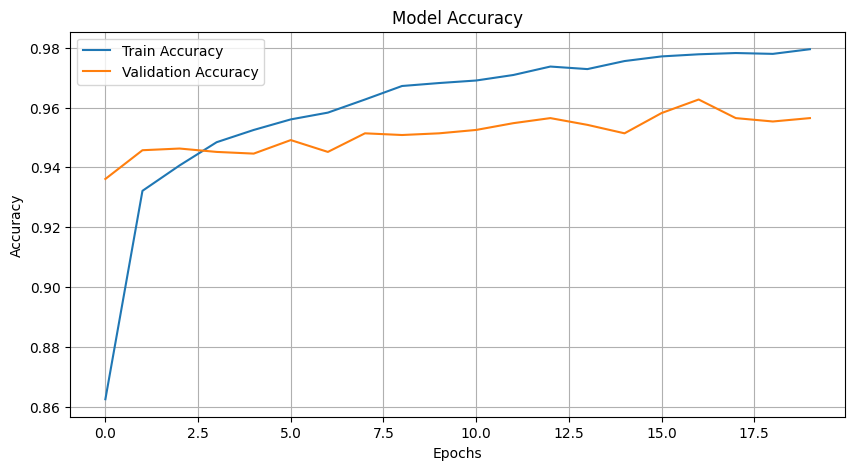

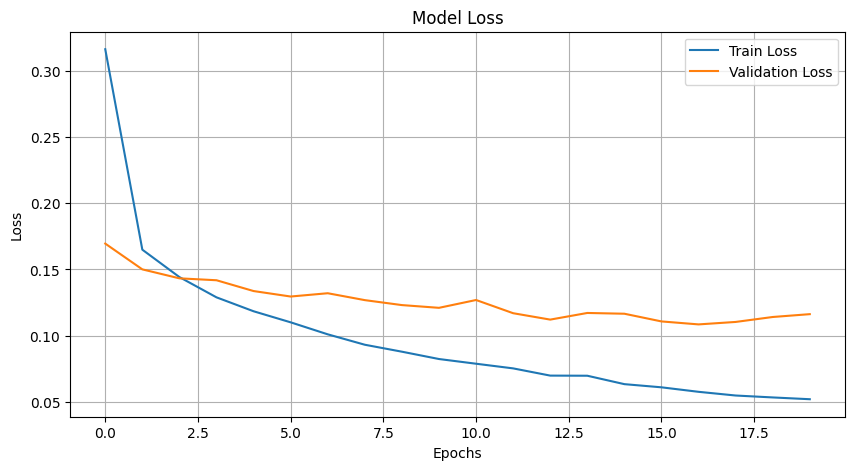

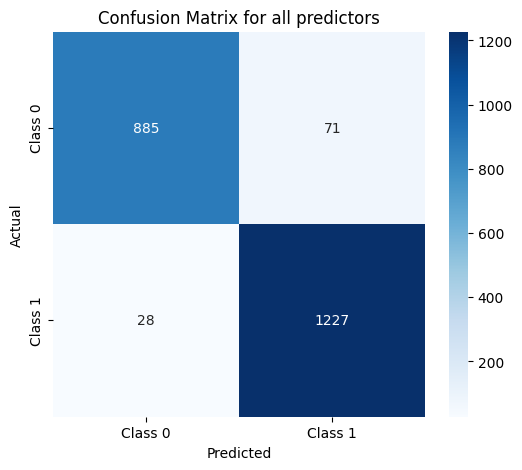

Brier Score: 0.0346


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

#predictions
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# ROC-AUC score
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_probs)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Plot accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid()
plt.show()

# Plot loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid()
plt.show()


conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix,annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix for all predictors")
plt.show()

brier_score = brier_score_loss(y_test, y_pred_probs)

print(f"Brier Score: {brier_score:.4f}")

After evaluating a model with 30 predictors, however in real life if we want to predict phishing links we not have time or the resources to check all 30 things to see if a link is spam. So we hypothesizes 4 categories to watch out for and help reduce our search.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

### Reduced Models (4 Categories)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Results for URL Features:
ROC-AUC Score: 0.9386
              precision    recall  f1-score   support

           0       0.95      0.71      0.81       956
           1       0.81      0.97      0.89      1255

    accuracy                           0.86      2211
   macro avg       0.88      0.84      0.85      2211
weighted avg       0.87      0.86      0.85      2211



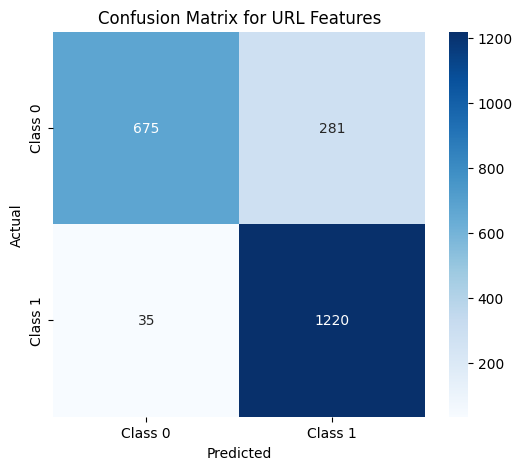

Brier Score: 0.0940


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Results for Security Features:
ROC-AUC Score: 0.9273
              precision    recall  f1-score   support

           0       0.88      0.87      0.88       956
           1       0.90      0.91      0.91      1255

    accuracy                           0.89      2211
   macro avg       0.89      0.89      0.89      2211
weighted avg       0.89      0.89      0.89      2211



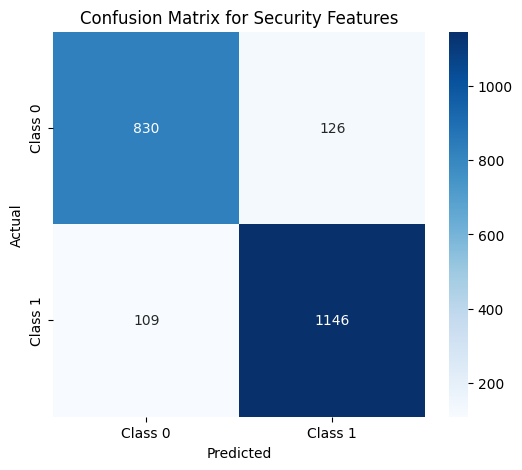

Brier Score: 0.0889


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Results for Page Features:
ROC-AUC Score: 0.7782
              precision    recall  f1-score   support

           0       0.67      0.64      0.66       956
           1       0.74      0.76      0.75      1255

    accuracy                           0.71      2211
   macro avg       0.70      0.70      0.70      2211
weighted avg       0.71      0.71      0.71      2211



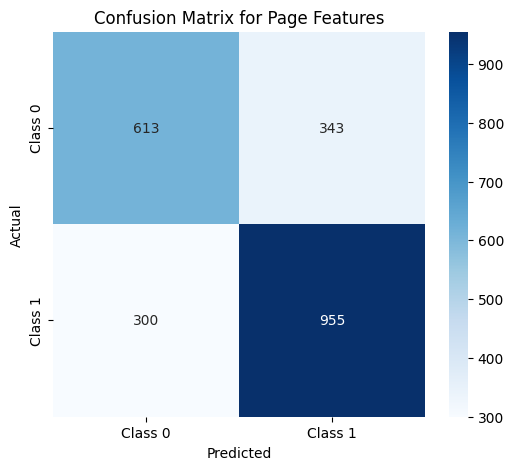

Brier Score: 0.1892


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Results for Domain Features:
ROC-AUC Score: 0.7779
              precision    recall  f1-score   support

           0       0.66      0.69      0.67       956
           1       0.75      0.73      0.74      1255

    accuracy                           0.71      2211
   macro avg       0.71      0.71      0.71      2211
weighted avg       0.72      0.71      0.71      2211



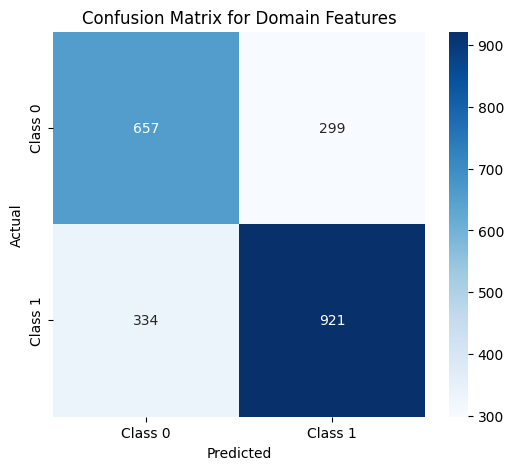

Brier Score: 0.1893


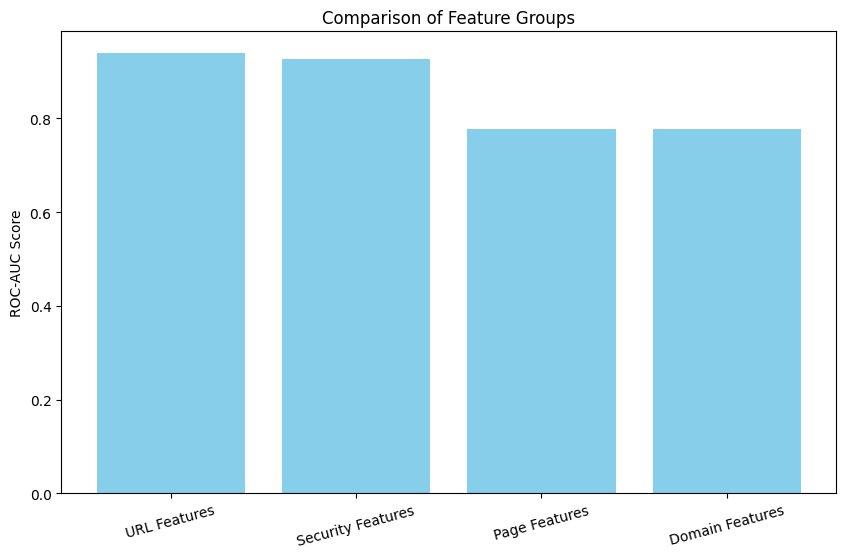

In [ ]:
# Feature groups
# URL Features
url_features = [
    'url_length', 'having_at_symbol', 'double_slash_redirecting',
    'prefix_suffix', 'shortining_service', 'url_of_anchor',
    'request_url', 'links_pointing_to_page', 'statistical_report',
    'abnormal_url'
]

# Security Features
security_features = [
    'sslfinal_state', 'https_token', 'favicon', 'redirect', 'port',
    'sfh', 'submitting_to_email', 'iframe', 'popupwindow'
]

# Page Features
page_features = [
    'web_traffic', 'google_index', 'page_rank',
    'on_mouseover', 'rightclick', 'links_in_tags'
]

# Domain Features
domain_features = [
    'domain_registration_length', 'age_of_domain', 'dnsrecord',
    'having_sub_domain', 'having_ip_address'
]

# Extract subsets for each group
X_url = data[url_features].values
X_security = data[security_features].values
X_page = data[page_features].values
X_domain = data[domain_features].values

# Target variable
y = (data["result"] == 1).astype(int)  # Binary target (0 or 1)

# Function to train and evaluate a neural network
def train_and_evaluate(X, y, group_name):
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Normalize features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Define the model
    model = Sequential([
        Dense(64, activation='relu', input_dim=X_train.shape[1]),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Train the model
    history = model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0, validation_split=0.2)

    # Evaluate the model
    y_pred_probs = model.predict(X_test)
    y_pred = (y_pred_probs > 0.5).astype(int)
    roc_auc = roc_auc_score(y_test, y_pred_probs)
    conf_matrix = confusion_matrix(y_test, y_pred)



    print(f"\nResults for {group_name}:")
    print(f"ROC-AUC Score: {roc_auc:.4f}")
    print(classification_report(y_test, y_pred))
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix,annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix for {group_name}")
    plt.show()

    brier_score = brier_score_loss(y_test, y_pred_probs)

    print(f"Brier Score: {brier_score:.4f}")


    return roc_auc

# Train and evaluate models for each feature group
roc_auc_url = train_and_evaluate(X_url, y, "URL Features")
roc_auc_security = train_and_evaluate(X_security, y, "Security Features")
roc_auc_page = train_and_evaluate(X_page, y, "Page Features")
roc_auc_domain = train_and_evaluate(X_domain, y, "Domain Features")

# Compare results
groups = ["URL Features", "Security Features", "Page Features", "Domain Features"]
scores = [roc_auc_url, roc_auc_security, roc_auc_page, roc_auc_domain]

# Plot ROC-AUC comparison
plt.figure(figsize=(10, 6))
plt.bar(groups, scores, color='skyblue')
plt.ylabel("ROC-AUC Score")
plt.title("Comparison of Feature Groups")
plt.xticks(rotation=15)
plt.show()


# Model Comparison and Evaluation

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.inspection import permutation_importance

# Define a custom wrapper with the required attributes
class KerasClassifierWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model):
        self.model = model
        self.classes_ = np.array([0, 1])  # Specify the classes explicitly

    def fit(self, X, y):
        pass  # No fitting required, as the model is pre-trained

    def predict(self, X):
        probs = self.model.predict(X)
        return (probs > 0.5).astype(int).flatten()  # Binary predictions (0 or 1)


70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
70/70 ━━━━━━━━━━━━━━━━━━━

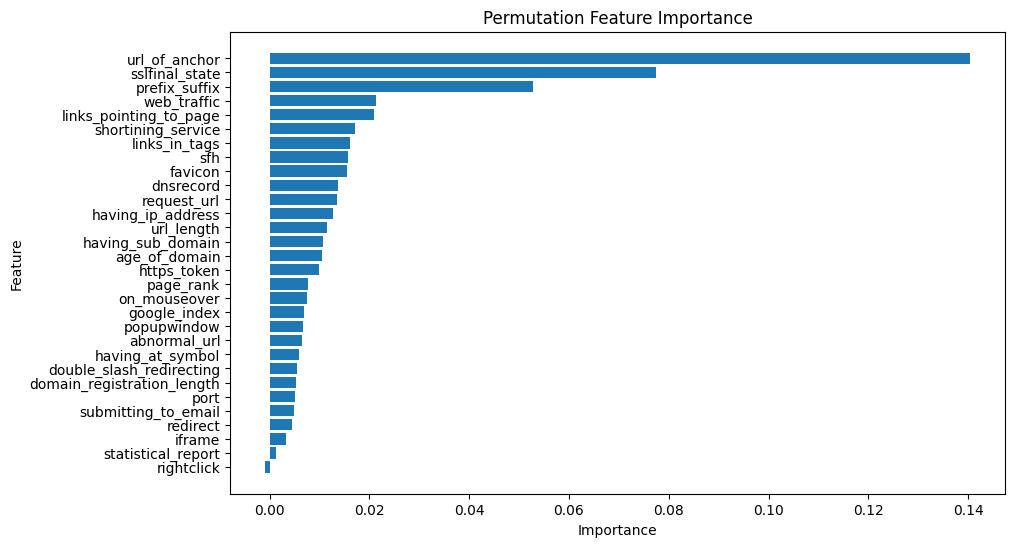

In [ ]:
# Wrap the trained neural network model
keras_model_wrapper = KerasClassifierWrapper(model)

# Compute permutation importance
results = permutation_importance(
    keras_model_wrapper, X_test, y_test,
    scoring='accuracy',
    n_repeats=10,
    random_state=42
)

# Create a DataFrame for feature importance
importance_df = pd.DataFrame({
    'Feature': data.columns[:-1],  # Exclude the target column
    'Importance': results.importances_mean
}).sort_values(by='Importance', ascending=False)

# Display the most important features
print("Permutation Feature Importance:")
print(importance_df)

# Plot feature importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Permutation Feature Importance')
plt.gca().invert_yaxis()
plt.show()


Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8888 - loss: 0.3835 - val_accuracy: 0.9327 - val_loss: 0.1858
Epoch 2/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9233 - loss: 0.1862 - val_accuracy: 0.9344 - val_loss: 0.1774
Epoch 3/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9267 - loss: 0.1709 - val_accuracy: 0.9339 - val_loss: 0.1719
Epoch 4/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9294 - loss: 0.1649 - val_accuracy: 0.9333 - val_loss: 0.1716
Epoch 5/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9318 - loss: 0.1555 - val_accuracy: 0.9322 - val_loss: 0.1681
Epoch 6/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9320 - loss: 0.1586 - val_accuracy: 0.9339 - val_loss: 0.1665
Epoch 7/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9358 - loss: 0.1518 - val_accuracy: 0.9237 - val_loss: 0.1685
Epoch 8/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9365 - loss: 0.1507 - val_accuracy: 0.9237 - val_

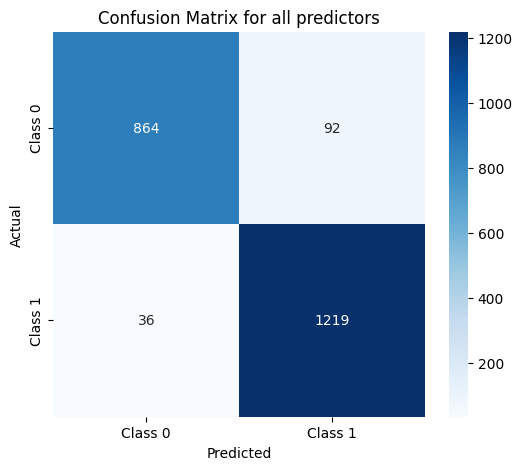

In [ ]:
# Based on importance analysis
best_features = [
    'url_of_anchor', 'prefix_suffix', 'sslfinal_state', 'web_traffic','having_sub_domain','links_in_tags','links_pointing_to_page'
]

X = data[best_features].values
y = (data["result"] == 1).astype(int)  # Convert target to binary (0 or 1)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize features using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build the neural network model
model = Sequential([
    Dense(64, activation='relu', input_dim=X_train.shape[1]),  # Input and hidden layer
    Dense(32, activation='relu'),                              # Hidden layer
    Dense(1, activation='sigmoid')                             # Output layer
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=BinaryCrossentropy(),
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

# Make predictions
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# Generate classification report and ROC-AUC score
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_probs)
print(f"ROC-AUC Score: {roc_auc:.4f}")


conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix,annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix for all predictors")
plt.show()


In [ ]:
from sklearn.metrics import brier_score_loss

# Calculate Brier Score for the predictions
brier_score = brier_score_loss(y_test, y_pred_probs)

brier_score


0.04468417823878763

# Conclusions and Implications

Through our analysis using a logistic regression model, a decision tree model, and neural network model, we have concluded that

1.   There are 7 minimum variables needed to predict phishing websites as per the decision tree and neural network. These are URL of anchor, ssl final, prefix-suffix, web traffic, having sub domain, and links in tags. According to the decision tree, the last variable is the request url. On the other hand, the neural network found that the last variable is the number of links pointing to the page.
2.   Variables associated domain and URL features are the most important, with security features following. No predictors associated with page features were selected by any model.
3. The neural network was the best model when looking at Brier score and ROC-AUC scores.

Overall, all three models we built were successful. The logistic regression model achieved a high test accuracy of 92.4%, and had relatively low Brier scores of 0.53 and 0.053 for the training and testing scores respectively. This suggests that the model does not overfit but rather generalizes well. We also regularized our results through LASSO, which resulted in a slightly higher accuracy value of 92.7% and a lower Brier score of 0.0059. It stated that URL and Security Features are significant, which provide a strong reduced model.

With the second model we built, the decision tree, we approached this model with two approaches. The first limited the depth of the tree to 6. Our Brier scores were slightly higher compared to the logistic regression model, with 0.099 and 0.095 for training and testing sets respectively. The second decision tree limited the sample size of each node, which resulted in a Brier score of 0.084 and 0.091 for training and test sets respectively. We concluded that URL and Security Features were the best at predicting phishing websites as they had the lowest Brier scores among the 4 groups, at 0.168 and 0.169.
Finally, our neural network models were promising as well. They had high ROC-AUC scores, which suggests that it is able to differentiate between phishing websites and legitimate websites well. Furthermore, they had low brier scores of 0.094 which suggests that they generalize well. The full model using all the predictors outperformed the other models due to accessibility to the data, but the other two submodels had a similar output and would be good enough in a situation without all variables. Ultimately, the neural network models were the best out of the three we built since they had the lowest Brier score while also having the highest F1 score. This suggests that it has the best precision and recall and also generalizes well.

The conclusions we have found could be used in the future to create tools such as web extensions that flag websites and protect users from phishing attacks. Unfortunately, there have been new avenues for phishing available to attacks as new technologies evolve. For example, the rise of artificial intelligence (AI) has made it easier for assailants to create more sophisticated and convincing attacks. They can easily correct common grammatical and formatting errors, thus making it harder for the average person to flag these attacks. Furthermore, techniques such as Voice Phishing (vishing) have become more compelling as AI is able to mimic the voices of trustworthy persons. As a result, some of the variables we have evaluated in this project may become outdated as technologies grow, and new flags that are not considered may populate.

In the future, we should look towards how to prevent phishing now that we know what flags to look for. More specifically, the two populations that need more attention would be those in society who are the most vulnerable - the elderly and children - as well as those in the workforce that guard sensitive information to prevent it from being leaked to attackers. Ultimately, these are long term projects that would need further data collection and analysis, but could lead to very significant improvements to society’s well being.


# Sources


Brownell, Natalie. “What Is WHOIS and How Is It Used?” Domain.com | Blog, 17 July 2020, www.domain.com/blog/what-is-whois-and-how-is-it-used/.

Cisco Talos Intelligence Group. “PhishTank > Frequently Asked Questions (FAQ).” Phishtank.com, 2024, www.phishtank.com/faq.php#what. Accessed 6 Dec. 2024.

FBI. “Internet Crime Complaint Center Releases 2022 Statistics.” Federal Bureau of Investigation, 22 Mar. 2023, www.fbi.gov/contact-us/field-offices/springfield/news/internet-crime-complaint-center-releases-2022-statistics.

Mohammad, Rami, McCluskey, T.L. and Thabtah, Fadi (2012) An Assessment of Features Related to Phishing Websites using an Automated Technique. In: International Conferece For Internet Technology And Secured Transactions. ICITST 2012 . IEEE, London, UK, pp. 492-497. ISBN 978- 1-4673-5325-0

Singh, Maninder. “Understanding Categorical Correlations with Chi-Square Test and Cramer’s V.” Medium, 19 Oct. 2023, medium.com/@manindersingh120996/understanding-categorical-correlations-with-chi-square-test-and-cramers-v-a54fe153b1d6.

Wikipedia Contributors. “Alexa Internet.” Wikipedia, Wikimedia Foundation, 27 Aug. 2019, en.wikipedia.org/wiki/Alexa_Internet.
